## ATSEviz: Visualizing Alternative Splicing Events
This notebook demonstrates how to use the ATSEviz module from LeafletFA-utils to visualize alternative splicing events.

In [ ]:
# Import necessary libraries
import pandas as pd
import os
import sys
import pandas as pd
import numpy as np
from typing import List, Set

# Add main path to sys.path
module_path = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [2]:
db_file = "/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250401_150841/annotation.db"
db = gffutils.FeatureDB(db_file, keep_order=True)

In [18]:
# Visualize random ATSEs
p=pd.read_csv("/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250405_105120/atse_events_20250405-105714.tsv.gz", sep="\t")
atse_event = p.sample(1)["event_id"].values[0]

# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = p[p["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)
splice_junctions

[{'chrom': 'chr9',
  'start': 120130363,
  'end': 120130808,
  'name': 'junction_9',
  'strand': '+',
  'usage_ratio': 0.06419529837251356},
 {'chrom': 'chr9',
  'start': 120130363,
  'end': 120130767,
  'name': 'junction_10',
  'strand': '+',
  'usage_ratio': 0.9358047016274864}]

In [19]:
def extract_unique_transcripts(juncs: pd.DataFrame) -> List[str]:
    """
    Extract unique transcripts from all transcript-related columns in junction DataFrame.
    Handles string lists, NA values, and ensures uniqueness.
    
    Args:
        juncs: DataFrame containing junction data with transcript columns
        
    Returns:
        List of unique transcript IDs
    """
    # Columns to extract transcripts from
    transcript_columns = [
        "both_ends_transcripts", 
        "only_5_prime_transcripts", 
        "only_3_prime_transcripts", 
        "perfect_match_5_prime", 
        "perfect_match_3_prime"
    ]
    
    # Set to store unique transcripts
    all_transcripts: Set[str] = set()
    
    # Process each column
    for column in transcript_columns:
        if column not in juncs.columns:
            print(f"Warning: Column '{column}' not found in DataFrame")
            continue
            
        # Process each row in the column
        for value in juncs[column]:
            # Skip NA/None values
            if pd.isna(value) or value == 'NA' or value is None:
                continue
                
            # Handle string lists (comma-separated values)
            if isinstance(value, str):
                # Skip empty strings
                if value.strip() == '':
                    continue
                    
                # Split by comma and add each transcript to the set
                for transcript in value.split(','):
                    transcript = transcript.strip()
                    if transcript and transcript != 'NA':
                        all_transcripts.add(transcript)
            
            # Handle actual Python lists
            elif isinstance(value, list):
                for transcript in value:
                    if transcript and not pd.isna(transcript) and transcript != 'NA':
                        all_transcripts.add(str(transcript))
    
    # Convert set to sorted list for consistent output
    return sorted(list(all_transcripts))

# Example usage:
unique_transcripts = extract_unique_transcripts(juncs)
print(f"Found {len(unique_transcripts)} unique transcripts")

Found 5 unique transcripts


                     transcript_name          transcript_type  \
ENSMUST00000035105.6        Rpsa-201           protein_coding   
ENSMUST00000215568.1        Rpsa-202          retained_intron   
ENSMUST00000217317.1        Rpsa-204           protein_coding   
ENSMUST00000217352.1        Rpsa-205  nonsense_mediated_decay   
ENSMUST00000217356.1        Rpsa-206  nonsense_mediated_decay   

                             transcript_id  
ENSMUST00000035105.6  ENSMUST00000035105.6  
ENSMUST00000215568.1  ENSMUST00000215568.1  
ENSMUST00000217317.1  ENSMUST00000217317.1  
ENSMUST00000217352.1  ENSMUST00000217352.1  
ENSMUST00000217356.1  ENSMUST00000217356.1  
Plot saved to test.pdf!


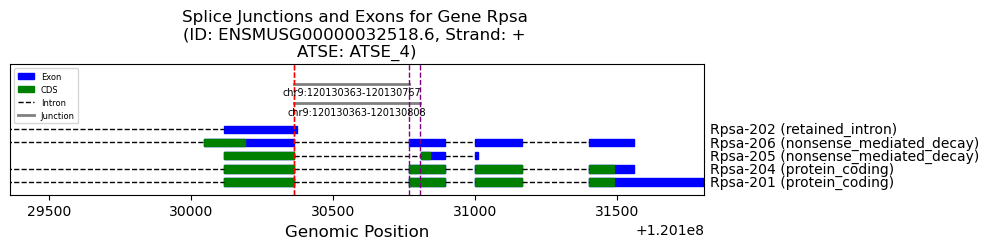

In [21]:
# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=10, trans_height=0.3, show_usage=False, show_junc_lines=True, filename="test.pdf")

# TO-DO:
# - Return plot as a plot object that users can add additional things to... matplotlib object? ax... concatenate... 
# - Feed in OG Leafcutter Intron Clusters... via intron cluster table... 
# - Feed in the Junction by Sample Table as input to junction annoation... BED file with extra columns... 
# - Similar to isoform plots, implement the intron scaling thing
# - VIsulize multiple ATSEs per gene wuld be nice 
# - Test on BigBrain bulk RNA-seq files 
# - Test on EasySci junctions 
# - sQTLs or other SNPs would be nice to visualize... 

In [28]:
juncs.iloc[1]["perfect_match_5_prime"], juncs.iloc[1]["perfect_match_3_prime"]

('ENSMUST00000035105.6,ENSMUST00000217356.1,ENSMUST00000217317.1,ENSMUST00000217352.1',
 'ENSMUST00000035105.6,ENSMUST00000217356.1,ENSMUST00000217317.1')

In [ ]:
def check_junction_annotation(splice_junctions, db, tolerance=1):
    junction_labels = []
    for junction in tqdm(splice_junctions):
        chrom = junction["chrom"]
        start = junction["start"]
        end = junction["end"]
        strand = junction.get("strand", "+")
        label_5_prime, label_3_prime = "unannotated on 5'", "unannotated on 3'"
        position_off_5_prime, position_off_3_prime = None, None

        transcripts = list(
            db.region(
                region=(chrom, start - 1000, end + 1000), featuretype="transcript"
            )
        )

        # Initialize an empty set for transcript IDs to avoid duplicates
        transcripts_junc = set()

        for transcript in transcripts:
            exons = list(db.children(transcript, featuretype="exon", order_by="start"))

            if strand == "+":
                for exon in exons:
                    if abs(exon.end - start) <= tolerance:
                        label_5_prime = "annotated on 5'"
                        position_off_5_prime = exon.end - start
                        transcripts_junc.add(transcript.id)
                        break
                for exon in exons:
                    if abs(exon.start - end) <= tolerance:
                        label_3_prime = "annotated on 3'"
                        position_off_3_prime = exon.start - end
                        break
            elif strand == "-":
                for exon in exons:
                    if abs(exon.start - end) <= tolerance:
                        label_5_prime = "annotated on 5'"
                        position_off_5_prime = exon.start - end
                        transcripts_junc.add(transcript.id)
                        break
                for exon in exons:
                    if abs(exon.end - start) <= tolerance:
                        label_3_prime = "annotated on 3'"
                        position_off_3_prime = exon.end - start
                        transcripts_junc.add(transcript.id)
                        break

        junction_labels.append(
            {
                "junction": f"{chrom}:{start}-{end}",
                "strand": strand,
                "label_5_prime": label_5_prime,
                "label_3_prime": label_3_prime,
                "position_off_5_prime": position_off_5_prime,
                "position_off_3_prime": position_off_3_prime,
                "transcripts": list(transcripts_junc),
            }
        )
    return junction_labels

In [ ]:
check_junction_annotation(splice_junctions, db, tolerance=1)

In [ ]:
juncs.iloc[0]["both_ends_transcripts"]

In [ ]:
juncs.iloc[0]